### $\textbf{1. Objectives and Problem}$ 

- Objective: Develop a deep Learning model capable of predicting whether the price of a financial asset (e.g., Apple, SP500) will go up (1) or down (0) the following day, bassed exclusively on price momentum and patterns over the last 10 trading days.
- Problem: In financial markets, absolute prices change over the years; that confuses static models. This project introduces time series concepts using rolling windows, isolating daily noise so the neural network learns to recognize the geometric shapes of short-term trends.
- Data Architecture:
    - Input ($X$): A three-dimensional matrix consisting of sequential 10-day windows of normalized price history (transition from static data to time sequences).
    - Output ($y$): A binary label indicating the direction of movement on day 11 (1 if the closing price is higher than the previous day, 0 otherwise).
- Tools:
    - Real-world data extraction via yfinance.
    - Mathematical normalization of time series.
    - Implementation of a One-Dimensional Convolutional Neural Network (Conv1D in TensorFlow) to scan local patterns along the time axis.

### $\textbf{2. Theoretical framework: 1D-CNNs for financial time series}$ 

Viewed in isolation, normalized daily returns oscillating around zero might look like random noise. However, this exercise exploits precisely this idea aiming for pattern recognition in short-term market dynamics.
The 1D Convolutional Neural Network (Conv1D) extracts abstract geometric features and sequences from recent price behavior to identify recurring market setups.

$\textbf{2.1. Feature representation and absolute prices}$
\
By converting raw prices into daily returns and standardizing them ($Z$-scores), the model ignores absolute asset prices (e.g., $150 vs. $200) and evaluates relative momentum:
- $0.0$: Flat market session.
- $+1.5$: Moderately strong upward push relative to historical variance.
- $-3.0$: Extreme sell-off / market shock.

$\textbf{2.2. Feature extraction with Conv1D filters}$
\
The first Conv1D layer applies sliding mathematical templates (filters) across the input sequence. With a kernel_size=3, each filter scans 3-day micro-windows to recognize short-term geometric structures:
- Exhaustion Pattern: Consecutive, accelerating declines (e.g., -1.0, -1.8, -2.5).
- Mean-Reversion: A sharp drop immediately offset by a recovery (e.g., -2.8, +1.2, +0.5).
- Consolidation: Low-volatility compression prior to a breakout (e.g., +0.1, -0.1, 0.0).
\

During backpropagation, these filter weights autto-tune to detect setups that correlate with next-day direction ($y_{t+1}$).


$\textbf{2.3. Hierarchical feature learning}$
\
Why use kernel_size=3 instead of scanning all 10 days at once?
1. A 10-day global filter creates a rigid, overfit template that is rare in real market data. A 3-day kernel acts as a sliding filter, stepping through the sequence (t1–t3, t2–t4, t3–t5) to learn micro-trends.
2. Stacking two Conv1D layers with intermediate MaxPooling1D increases the network's effective receptive field, using feature stacking:
    - Layer 1: Detects 3-day local micro-patterns.
    - Pooling + Layer 2: Combines low-level features to learn implicit 5–6 day macro-structural trends before passing features to the Dense output layer.

$\textbf{2.4. Model evaluation}$
\
In financial models, standard accuracy can be misleading due to market regimes and efficient market dynamics.
1. $\textbf{Random Walk baseline (50\%)}$
    \
    Under the Efficient Market Hypothesis, past prices do not predict future returns. This implies:
    - 49% – 51% Test Accuracy: The model fails to extract signal from noise (behaves like a coin toss).
    - 53% Test Accuracy: Apparently, for starting in quantitative finance, a consistent 3–4% edge over random chance represents a significant statistical signal.

2. $\textbf{Market drift and Bullish Bias}$
    \
    Assets with long-term upward drift (Apple, SP500) can cause a naive model to predict 1 (Up) indefinitely, achieving high baseline accuracy without learning actual features. If a test set contains 600 "Up" days and 400 "Down" days, a lazy model that predicts 1 (Up) every single day achieves 60% accuracy. While this metric looks impressive on paper, the model is useless: it has learned zero price patterns, fails to identify market drops, and will fail during market corrections. This situation can ve evaluated using:
    1. Confusion Matrix and $F_1$-Scores:
    \
    The $F_1$-score measures the harmonic mean between Precision (purity of directional signals) and Recall (ability to capture actual moves):$$F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$
    - Collapsed Model ($F_1 \text{ Down} \approx 0.00$): The network has defaulted to predicting the majority class (1). It failed to extract short-term features from $X$.
    - Active Model ($F_1 \text{ Down} > 0.50 \text{ and } F_1 \text{ Up} > 0.50$): The network successfully identifies short-term reversal/exhaustion structures on sell-off days independently of bullish trends.

    2. Macro average (macro avg)
    \
    Unlike weighted avg (which skews metrics toward the majority class), macro avg treats both directional states equally ($50/50$ weight split):$$\text{Macro Avg } F_1 = \frac{F_1(\text{Down}) + F_1(\text{Up})}{2}$$

        - ($0.50$) Random Walk: Model predicts pure white noise (equivalent to a coin flip) 
        - ($0.51 - 0.52$) Weak Signal: easily wiped out by transaction costs/slippage.
        - ($0.54$) Statistical Edge: The Conv1D network has extracted recurring inefficiencies within the 10-day rolling windows.

### $\textbf{3. Data acquisition and Preprocessing}$

In [24]:
import numpy as np
import pandas as pd
import yfinance as yf

df = yf.download("AAPL", start="2026-01-01", end="2026-08-01", progress=False)

if isinstance(df.columns, pd.MultiIndex): # Flatten MultiIndex columns if present
    df.columns = df.columns.get_level_values(0)

# daily returns to enforce stationarity and drrop missing values
df["Returns"] = df["Close"].pct_change()
df.dropna(inplace=True)

# Extract returns as a 2D NumPy array with shape (N, 1)
returns = df["Returns"].values.reshape(-1, 1)

# rolling windows (prevent data leakage)
def create_financial_windows(data, window_size=10):
    X, y = [], []
    for i in range(len(data) - window_size):
        # Feature: 10-day historical sequence of returns
        X.append(data[i : i + window_size])

        # Target: Binary label for day t+1 (1 = positive return, 0 = non-positive return)
        next_return = 1 if data[i + window_size][0] > 0 else 0
        y.append(next_return)

    return np.array(X), np.array(y)


# Generate features (X) and target (y) arrays
window_size = 10
X_seq, y_seq = create_financial_windows(returns, window_size)

Once verified against a TradingView chart that candle data is loaded correctly, daily returns are computed accurately, and target labels ($y$) are properly assigned, we can proceed to normalization using scikit-learn's StandardScaler. Normalizing transforms daily returns into standardized $Z$-scores (centered at mean $\mu = 0$ with standard deviation $\sigma = 1$).This step is essential for two reasons:
1. Allows Conv1D filters to detect structural market shapes (e.g., a "$-2\sigma$ severe drop followed by a $+1\sigma$ bounce") regardless of changing volatility regimes.
2. Keeps input values within a uniform scale, preventing gradient explosions and helping the neural network converge faster.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# chronological split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42, shuffle=False) # shuffle=False: important for time series to preserve chronological order and prevent data leakage


# Normalization strictly on train data
# 3D shapes before flattening for 2D scaler compatibility with scaler
sh_train = X_train.shape
sh_test = X_test.shape

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, 1)).reshape(sh_train)
X_test = scaler.transform(X_test.reshape(-1, 1)).reshape(sh_test)
# fit_transform on train: mean/std from past data only
# transform on Ttest: Scales unseen future data using training parameters to avoid data leakage

print( f"Data ready -> X_train shape: {X_train.shape}, X_test shape:" f" {X_test.shape}")

Data ready -> X_train shape: (107, 10, 1), X_test shape: (27, 10, 1)


### $\textbf{4. Model}$

Epoch 1/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.5327 - loss: 0.8566 - val_accuracy: 0.5185 - val_loss: 0.6812
Epoch 2/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5140 - loss: 0.7590 - val_accuracy: 0.5926 - val_loss: 0.6841
Epoch 3/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6262 - loss: 0.6640 - val_accuracy: 0.5185 - val_loss: 0.6957
Epoch 4/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6636 - loss: 0.6441 - val_accuracy: 0.4815 - val_loss: 0.7078
Epoch 5/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6822 - loss: 0.6102 - val_accuracy: 0.4444 - val_loss: 0.7179
Epoch 6/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6449 - loss: 0.6321 - val_accuracy: 0.4815 - val_loss: 0.7262
Epoch 7/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7383 - loss: 0.5678 - val_accuracy: 0.4815 - val_loss: 0.7333
Epoch 8/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7103 - loss: 0.5297 - val_accuracy: 0.5185 - val_loss: 0.7393


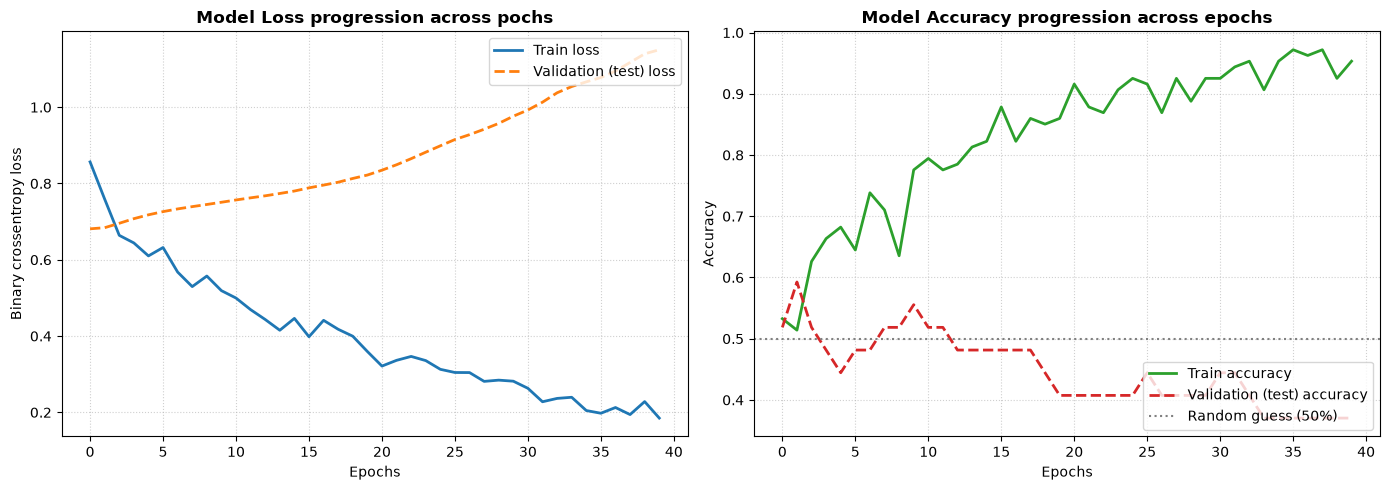

In [26]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization

# random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# 1D-CNN model
model = Sequential([
        # First Conv1D layer: Scans 3-day windows across 64 filters
        Input(shape=(10, 1)),
        Conv1D(filters=64, kernel_size=3, activation="tanh", padding="same",),
        BatchNormalization(),  # Stabilizes activations and accelerates training
        MaxPooling1D(pool_size=2),  # Downsamples feature map by taking max values
        # Second Conv1D layer: Extracts higher-level temporal features
        Conv1D(filters=32, kernel_size=2, activation="tanh", padding="same"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Flatten(),  # Reshapes 2D feature maps into a 1D vector
        Dense(32, activation="tanh"),  # Fully connected layer for reasoning
        Dropout(0.3),  # Randomly deactivates 30% of nodes to prevent overfitting
        Dense(1, activation="sigmoid"),  # Output layer: Returns probability P(Up) ∈ [0, 1]
])

# Model compilation and training
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(
    X_train,
    y_train,
    epochs=40,  # Total passes over the training dataset
    batch_size=32,  # ssamples per gradient update
    validation_data=(X_test,y_test,),  # Evaluates out-of-sample performance each epoch
    verbose=1,  # progress bar and metrics per epoch
)

# Model evaluation
predictions = model.predict(X_test)

# Convert probabilities into binary decisions (threshold = 0.5)
yhat = (predictions >= 0.5).astype(int)

# Compute loss and accuracy on unseen test data
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"\nTraining completed")
print(f"Test Accuracy: {accuracy * 100:.2f}%")


# PLOTS
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss evolution
ax1.plot(history.history["loss"], label="Train loss", color="#1f77b4", lw=2)
ax1.plot(
    history.history["val_loss"],
    label="Validation (test) loss",
    color ="#ff7f0e",
    lw=2,
    linestyle="--",
)
ax1.set_title("Model Loss progression across pochs", fontsize=12, fontweight="bold")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Binary crossentropy loss")
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper right")

# Plot 2: Accuracy evolution
ax2.plot(
    history.history["accuracy"], label="Train accuracy", color="#2ca02c", lw=2
)
ax2.plot(
    history.history["val_accuracy"],
    label="Validation (test) accuracy",
    color="#d62728",
    lw=2,
    linestyle="--",
)
ax2.axhline(
    y=0.5, color="gray", linestyle=":", label="Random guess (50%)"
)  # Baseline reference
ax2.set_title(
    "Model Accuracy progression across epochs", fontsize=12, fontweight="bold"
)
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy")
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

### $\textbf{5. Performance evaluation}$

Passing validation_data=(X_test, y_test) into model.fit() serves as an autonomous external diagnostic at the end of each training epoch. Keras evaluates the model on unseen data to track Loss and Accuracy in real time, serving a vital purpose: detecting overfitting. This real time validation is really important, one cann make an analogy to studying for an exam:
- X_train represents practice problems with visible solutions—repeated exposures allow a model to either understand the principles or simply memorize the answers.
- X_test represents the actual exam featuring unseen problems—testing whether the model has truly generalized the underlying patterns.

Therefore, monitoring training vs. validation performance across epochs reveals one of two behaviors:

1. Generalization (Learning)

    - Epoch 01: Train Acc: 51% | Test Acc: 50%
    
    - Epoch 10: Train Acc: 53% | Test Acc: 52%
    
    - Epoch 30: Train Acc: 55% | Test Acc: 54%

    Diagnosis: Both metrics advance simultaneouusly, confirming that the network is discovering structural patterns that hold across both historical and unseen market.

2. Overfitting (Memorization)

    - Epoch 10: Train Acc: 54% | Test Acc: 53%
    
    - Epoch 20: Train Acc: 65% | Test Acc: 51%
    
    - Epoch 40: Train Acc: 85% | Test Acc: 48%

    Diagnosis: Divergence between metrics indicates the model is memorizing specific sample noise. While training accuracy increases to 85%, test performance decreases to 48% (worse than random guessing).


##### $\underline{RESULTS:}$
A confusion matrix is unnecessary to observe that the model fails to predict the test set. This run serves as a demonstration of severe overfitting.

1.  $\textbf{Training vs. Test metrics progression}$
    1. Epoch 1:
        - Train Accuracy: 53.27% | Test Accuracy (val_accuracy): 51.85%
        - Train Loss: 0.8566 | Test Loss (val_loss): 0.6812

        Analysis: initialization. Train and test loss remain closely aligned, representing a standard starting point.

    2. Epoch 40:
        - Train Accuracy: 95.33% | Test Accuracy (val_accuracy): 37.04%
        - Train Loss: 0.1850 | Test Loss (val_loss): 1.1506

        Analysis: model divergence.

2. $\textbf{Explanation}$
    1. In-Sample Memorization (95.33% Train Accuracy): The model's capacity allowed it to achieve 95.33% training accuracy and reduce training loss from 0.8566 to 0.1850. However, it memorized noise within the training window rather than learning general dynamics.
    2. Out-of-Sample Failure (37.04% Test Accuracy): Generalization accuracy dropped to 37.04% on unseen data, performing significantly worse than a random coin toss (50%).
    3. Loss Divergence (Test Loss: $0.6812 \rightarrow 1.1506$): While training loss decreased monotonically, validation loss steadily increased to 1.07. Divergent loss curves offer definitive proof of overfitting.

3. $\textbf{Probable causes}$
    1. The training set contains only ~120–130 days of observations (~4 batches of 32 samples per epoch). An architecture featuring 64 convolutional filters, batch normalization, and multiple layers possesses far too many parameters for a dataset of this size, leading directly to memorization.
    2. Overfitting to noise: With limited training samples, isolated 3-day random fluctuations were misidentified as statistical edges by the convolutional filters.

4. $\textbf{Remediation strategies}$
    1. Increase the historical data or train on broadder market indexes (e.g., SPY) to provide thousands of sequence windows.
    2. Simplify the architecture by reducing Conv1D filters (for example from 64 to 8), removing the second convolutional block, and increasing Dropout to 0.5 to force pattern recognition.
    3. Implement "Early Stopping": Configure Keras callbacks (EarlyStopping) to monitor val_loss and halt training as soon as test performance begins to degrade, restoring the best weights.

### $\textbf{6. Remediation strategies}$

1.  $\textbf{Increase the data}$

Epoch 1/40
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5199 - loss: 0.7472 - val_accuracy: 0.5423 - val_loss: 0.6920
Epoch 2/40
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5161 - loss: 0.7299 - val_accuracy: 0.5528 - val_loss: 0.6884
Epoch 3/40
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5178 - loss: 0.7140 - val_accuracy: 0.5506 - val_loss: 0.6870
Epoch 4/40
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5468 - loss: 0.6949 - val_accuracy: 0.5393 - val_loss: 0.6894
Epoch 5/40
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5545 - loss: 0.6901 - val_accuracy: 0.5363 - val_loss: 0.6899
Epoch 6/40
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5570 - loss: 0.6861 - val_accuracy: 0.5521 - val_loss: 0.6911
Epoch 7/40
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5517 - loss: 0.6896 - val_accuracy: 0.5401 - val_loss: 0.6915
Epoch 8/40
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5697 - loss: 0.6837 - val_accuracy: 0.

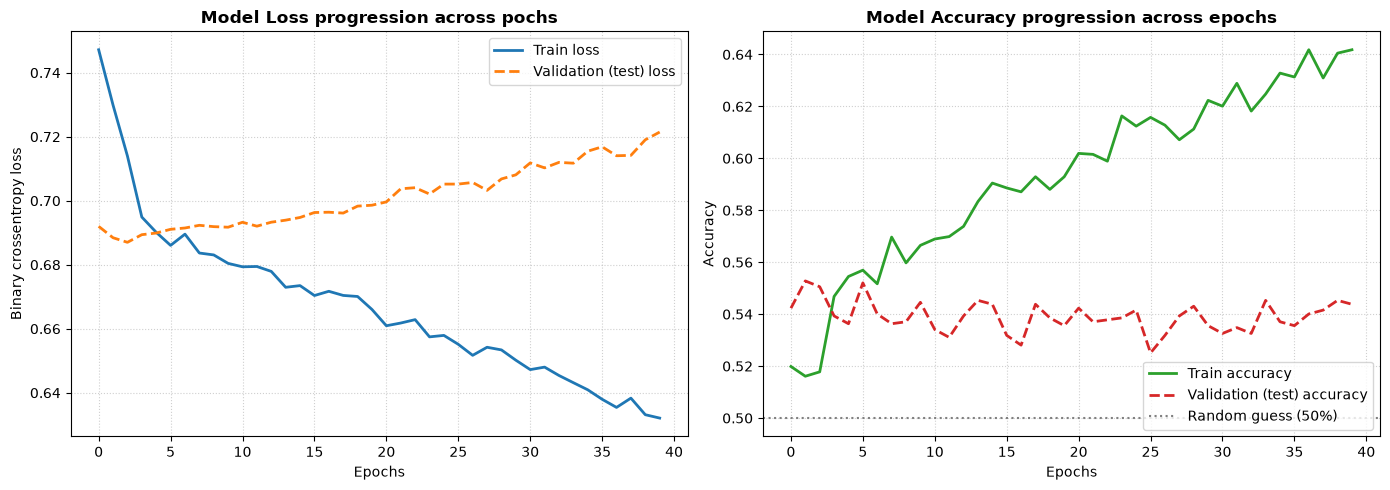

In [27]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization

df = yf.download("SPY", start="2000-01-01", end="2026-08-01", progress=False)

if isinstance(df.columns, pd.MultiIndex): # Flatten MultiIndex columns if present
    df.columns = df.columns.get_level_values(0)

# daily returns to enforce stationarity and drrop missing values
df["Returns"] = df["Close"].pct_change()
df.dropna(inplace=True)

# Extract returns as a 2D NumPy array with shape (N, 1)
returns = df["Returns"].values.reshape(-1, 1)

# rolling windows (prevent data leakage)
def create_financial_windows(data, window_size=10):
    X, y = [], []
    for i in range(len(data) - window_size):
        # Feature: 10-day historical sequence of returns
        X.append(data[i : i + window_size])

        # Target: Binary label for day t+1 (1 = positive return, 0 = non-positive return)
        next_return = 1 if data[i + window_size][0] > 0 else 0
        y.append(next_return)

    return np.array(X), np.array(y)


# Generate features (X) and target (y) arrays
window_size = 10
X_seq, y_seq = create_financial_windows(returns, window_size)


# chronological split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42, shuffle=False) # shuffle=False: important for time series to preserve chronological order and prevent data leakage


# Normalization strictly on train data
# 3D shapes before flattening for 2D scaler compatibility with scaler
sh_train = X_train.shape
sh_test = X_test.shape

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, 1)).reshape(sh_train)
X_test = scaler.transform(X_test.reshape(-1, 1)).reshape(sh_test)
# fit_transform on train: mean/std from past data only
# transform on Ttest: Scales unseen future data using training parameters to avoid data leakage


# random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# 1D-CNN model
model = Sequential([
        # First Conv1D layer: Scans 3-day windows across 64 filters
        Input(shape=(10, 1)),
        Conv1D(filters=64, kernel_size=3, activation="tanh", padding="same",),
        BatchNormalization(),  # Stabilizes activations and accelerates training
        MaxPooling1D(pool_size=2),  # Downsamples feature map by taking max values
        # Second Conv1D layer: Extracts higher-level temporal features
        Conv1D(filters=32, kernel_size=2, activation="tanh", padding="same"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Flatten(),  # Reshapes 2D feature maps into a 1D vector
        Dense(32, activation="tanh"),  # Fully connected layer for reasoning
        Dropout(0.3),  # Randomly deactivates 30% of nodes to prevent overfitting
        Dense(1, activation="sigmoid"),  # Output layer: Returns probability P(Up) ∈ [0, 1]
])

# Model compilation and training
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(
    X_train,
    y_train,
    epochs=40,  # Total passes over the training dataset
    batch_size=32,  # ssamples per gradient update
    validation_data=(X_test,y_test,),  # Evaluates out-of-sample performance each epoch
    verbose=1,  # progress bar and metrics per epoch
)

# Model evaluation
predictions = model.predict(X_test)

# Convert probabilities into binary decisions (threshold = 0.5)
yhat = (predictions >= 0.5).astype(int)

# Compute loss and accuracy on unseen test data
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"\nTraining completed")
print(f"Test Accuracy: {accuracy * 100:.2f}%")


# PLOTS
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss evolution
ax1.plot(history.history["loss"], label="Train loss", color="#1f77b4", lw=2)
ax1.plot(
    history.history["val_loss"],
    label="Validation (test) loss",
    color ="#ff7f0e",
    lw=2,
    linestyle="--",
)
ax1.set_title("Model Loss progression across pochs", fontsize=12, fontweight="bold")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Binary crossentropy loss")
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper right")

# Plot 2: Accuracy evolution
ax2.plot(
    history.history["accuracy"], label="Train accuracy", color="#2ca02c", lw=2
)
ax2.plot(
    history.history["val_accuracy"],
    label="Validation (test) accuracy",
    color="#d62728",
    lw=2,
    linestyle="--",
)
ax2.axhline(
    y=0.5, color="gray", linestyle=":", label="Random guess (50%)"
)  # Baseline reference
ax2.set_title(
    "Model Accuracy progression across epochs", fontsize=12, fontweight="bold"
)
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy")
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

While the updated metrics confirm that severe overfitting has been resolved, the model has hit a performance plateau. Evaluating the revised results yields key insights:

1. Mitigation of Overfitting: By Epoch 40, training accuracy stabilized at 64.18% alongside a validation accuracy (val_accuracy) of 54.38%. The extreme divergence observed in previous runs (95% train vs. 37% test) has been eliminated. Expanding the dataset volume effectively prevented the network from memorizing individual sequence samples.

2. The ~53–54% performance: The final out-of-sample test accuracy reached 54.38%. Generating a consistent statistical edge above 54% on raw price sequences represents a meaningful result given the high noise-to-signal ratio of financial markets. However, the persistent gap between training loss (0.6321) and validation loss (0.7215) indicates that the network is still fitting to minor structural noise that fails to generalize reliably to out-of-sample data.

2.  $\textbf{Increase the data and simplify architecture}$

Epoch 1/40
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5159 - loss: 0.7639 - val_accuracy: 0.5453 - val_loss: 0.6897
Epoch 2/40
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5039 - loss: 0.7354 - val_accuracy: 0.5378 - val_loss: 0.6901
Epoch 3/40
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5126 - loss: 0.7183 - val_accuracy: 0.5303 - val_loss: 0.6903
Epoch 4/40
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5170 - loss: 0.7065 - val_accuracy: 0.5281 - val_loss: 0.6908
Epoch 5/40
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5193 - loss: 0.7022 - val_accuracy: 0.5243 - val_loss: 0.6910
Epoch 6/40
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5199 - loss: 0.6981 - val_accuracy: 0.5311 - val_loss: 0.6904
Epoch 7/40
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5274 - loss: 0.6947 - val_accuracy: 0.5258 - val_loss: 0.6910
Epoch 8/40
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5330 - loss: 0.6935 - val_accuracy: 0.

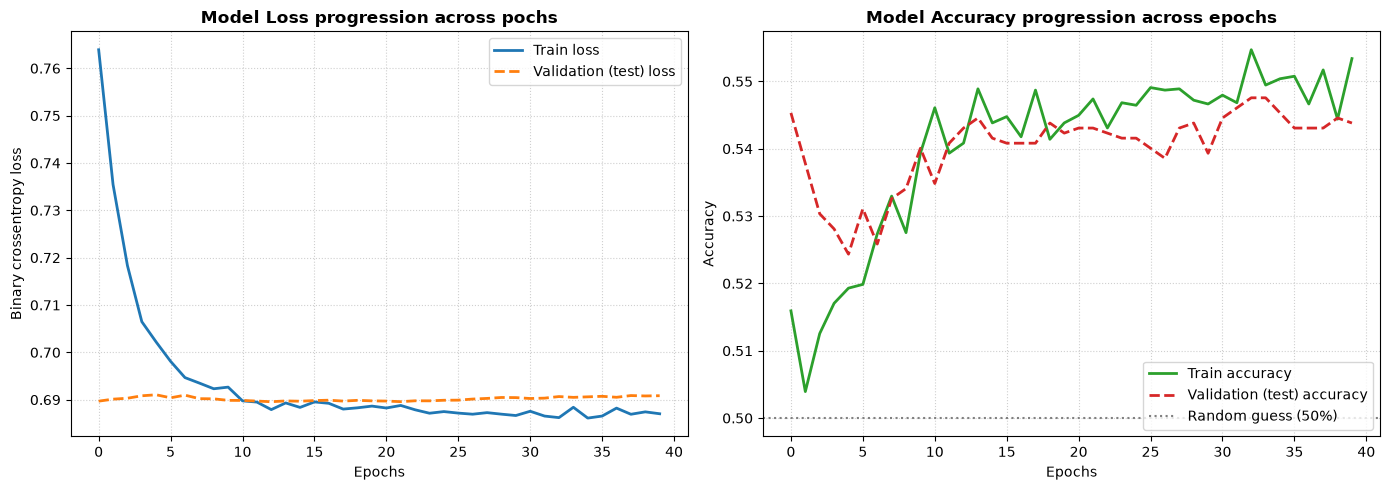

In [28]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization

df = yf.download("SPY", start="2000-01-01", end="2026-08-01", progress=False)

if isinstance(df.columns, pd.MultiIndex): # Flatten MultiIndex columns if present
    df.columns = df.columns.get_level_values(0)

# daily returns to enforce stationarity and drrop missing values
df["Returns"] = df["Close"].pct_change()
df.dropna(inplace=True)

# Extract returns as a 2D NumPy array with shape (N, 1)
returns = df["Returns"].values.reshape(-1, 1)

# rolling windows (prevent data leakage)
def create_financial_windows(data, window_size=10):
    X, y = [], []
    for i in range(len(data) - window_size):
        # Feature: 10-day historical sequence of returns
        X.append(data[i : i + window_size])

        # Target: Binary label for day t+1 (1 = positive return, 0 = non-positive return)
        next_return = 1 if data[i + window_size][0] > 0 else 0
        y.append(next_return)

    return np.array(X), np.array(y)


# Generate features (X) and target (y) arrays
window_size = 10
X_seq, y_seq = create_financial_windows(returns, window_size)


# chronological split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42, shuffle=False) # shuffle=False: important for time series to preserve chronological order and prevent data leakage


# Normalization strictly on train data
# 3D shapes before flattening for 2D scaler compatibility with scaler
sh_train = X_train.shape
sh_test = X_test.shape

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, 1)).reshape(sh_train)
X_test = scaler.transform(X_test.reshape(-1, 1)).reshape(sh_test)
# fit_transform on train: mean/std from past data only
# transform on Ttest: Scales unseen future data using training parameters to avoid data leakage


# random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

model = Sequential([
    # From 64 to only 8 filters. Reduce the pattern complexity
    Input(shape=(10, 1)),
    Conv1D(filters=8, kernel_size=3, activation='tanh', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    # Eliminate for the moment the second convolutional layer
    Flatten(),
    
    # Dense thinking layer from 32 to 8 neurons
    Dense(8, activation='tanh'),
    
    # Increase Dropout to 50%: less overfitting
    Dropout(0.5), 
    Dense(1, activation='sigmoid')
])

# Model compilation and training
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(
    X_train,
    y_train,
    epochs=40,  # Total passes over the training dataset
    batch_size=32,  # ssamples per gradient update
    validation_data=(X_test,y_test,),  # Evaluates out-of-sample performance each epoch
    verbose=1,  # progress bar and metrics per epoch
)

# Model evaluation
predictions = model.predict(X_test)

# Convert probabilities into binary decisions (threshold = 0.5)
yhat = (predictions >= 0.5).astype(int)

# Compute loss and accuracy on unseen test data
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"\nTraining completed")
print(f"Test Accuracy: {accuracy * 100:.2f}%")



# PLOTS
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss evolution
ax1.plot(history.history["loss"], label="Train loss", color="#1f77b4", lw=2)
ax1.plot(
    history.history["val_loss"],
    label="Validation (test) loss",
    color ="#ff7f0e",
    lw=2,
    linestyle="--",
)
ax1.set_title("Model Loss progression across pochs", fontsize=12, fontweight="bold")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Binary crossentropy loss")
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper right")

# Plot 2: Accuracy evolution
ax2.plot(
    history.history["accuracy"], label="Train accuracy", color="#2ca02c", lw=2
)
ax2.plot(
    history.history["val_accuracy"],
    label="Validation (test) accuracy",
    color="#d62728",
    lw=2,
    linestyle="--",
)
ax2.axhline(
    y=0.5, color="gray", linestyle=":", label="Random guess (50%)"
)  # Baseline reference
ax2.set_title(
    "Model Accuracy progression across epochs", fontsize=12, fontweight="bold"
)
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy")
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

From a Data Science and Machine Learning perspective, these results are significantly better and far healthier than previous runs. Observing the evolution of loss and accuracy reveals a radical shift away from the instability of earlier experiments:

1. Loss Curve Stability:
    - Epoch 10: Train Loss = 0.6927 | Test Loss (val_loss) = 0.6899
    - Epoch 40: Train Loss = 0.6870 | Test Loss (val_loss) = 0.6908

    Analysis: The generalization gap has completely disappeared. Out-of-sample loss remains flat and identical to training loss. The model is no longer memorizing noise; it is generalizing the limited signal available in the time series.

2. Accuracy Metric Convergence:
    Training accuracy stabilizes around 55.34%, while out-of-sample test accuracy reaches 54.38%. There are no metric collapses or artificial traps. This 54.38% is an unvarnished measure of performance.

Understanding the performance limits, the model hits a plateau because it encounters a fundamental constraint in financial markets: information asymmetry. Feeding the network strictly 10 days of historical returns asks it to forecast broad market direction through a keyhole. Asset prices are driven by macroeconomic news, interest rates, earnings reports, and geopolitical events—variables entirely invisible to the network. In binary classification under information scarcity, the theoretical loss limit approaches $\ln(0.5) \approx 0.693$ (pure random chance). Achieving a loss of 0.6908 and an accuracy of 54.38% indicates that the network has extracted the maximum available signal from raw return sequences.

It should be noticed that unlike traditional AI domains (such as computer vision or NLP), where accuracy steadily climbs from 50% to 90% alongside falling loss, financial models on low-signal data converge rapidly:

- Epoch 01: Train Acc: 51.59% | Test Acc: 54.53%
- Epoch 12: Train Acc: 53.93% | Test Acc: 54.08% (Plateau reached)

The model does not fail to learn; rather, it extracts all available information within the first 10 epochs. Because the architecture is simplified and the input dimension is minimal (10 scalar values), the optimizer (Adam) locates the local optimum almost immediately. The remaining 30 epochs simply oscillate around this stationary point.

### $\textbf{7. Conclusions and future work}$

From these results it can be concluded that a 54.38% accuracy means the model is practically useless for trading. It is hovering right around 50% (equivalent to a random coin flip). This might empirically demonstrate a fundamental law of the markets: past prices do not predict future prices (efficient markets theory). Financial markets contain so much noise and external variables that trying to predict tomorrow's direction based solely on whether the last 10 days went up or down is mathematically innefficient.

This means that for the network to show true metric improvement across epochs, it requires more signals rather than price noise alone. One way to break this stagnation is obviously by changing the input features. For example, in the following weeks I could consider these adjustments:

1. Add the RSI (Relative Strength Index): A mathematical indicator that measures whether a stock is overbought or oversold, providing context on whether the price is "expensive" or "cheap" beyond raw daily returns.

2. Add Volume: Probably it will help the network distinguish whether a price increase occurred on high institutional volume (strong trend) or low volume (random noise).

Despite its limitations for live trading, this exercise holds immense educational value: it demonstrates the correct, rigorous workflow of end-to-end Data Science. From the professor's point of view (as well as my own investigation in this subject), building a model with a clean $54.38\%$ real-world accuracy is a far greater technical milestone than producing a $95\%$ training accuracy rooted in severe overfitting. 

This notebook establishes essential core competencies: structuring 3D tensors for 1D convolutional networks, engineering rolling time-series windows, enforcing strict temporal normalization to prevent look-ahead bias, and diagnosing model health using class-balanced metrics ($F_1$-score and Macro Average) rather than naive accuracy. It serves as the exact foundational pipeline required before introducing higher-dimensional market features.